In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Wong-Wang Excitatory-Inhibitory (Dynamic Mean Field)

The **two-population (excitatory-inhibitory) reduced Wong-Wang model**, often called the *dynamic mean field* (DMF), is the resting-state workhorse for whole-brain modeling. Each region has an excitatory NMDA gating variable $S_E$ and an inhibitory GABA gating variable $S_I$; a feedback-inhibition weight $J_i$ regulates the local excitation-inhibition balance so that the excitatory population settles near a biologically plausible ~3 Hz resting rate. It is the node model behind much resting-state BOLD / functional-connectivity work.

*(Distinct from the reduced two-choice* `WongWangStep` *decision model.)*

**Reference:** Deco, Ponce-Alvarez, Hagmann, Romani, Mantini & Corbetta (2014), *How local excitation-inhibition ratio impacts the whole brain dynamics*, Journal of Neuroscience 34(23):7886-7898.

## Build the model

In [2]:
node = brainmass.WongWangExcInhStep(in_size=1, J_i=1.0, G=2.0)
node

WongWangExcInhStep(
  in_size=(1,),
  out_size=(1,),
  a_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(310., dtype=float32)
  ),
  b_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(125., dtype=float32)
  ),
  d_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.16, dtype=float32)
  ),
  gamma_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.000641, dtype=float32)
  ),
  tau_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(100., dtype=float32)
  ),
  w_p=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1.4, dtype=float32)
  ),
  W_e=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  ),
  a_i=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(615., dtype=float32)
  ),
  b_i=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(177., dtype=float32)
  ),
  d_i=Const(
    fit=False,
   

## Run a simulation

We monitor the excitatory gating variable `S_e` and the derived excitatory firing rate via the `H_e()` observable.

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(3000. * u.ms,
              monitors={'S_e': 'S_e', 'rate_e': lambda m: m.H_e()})
float(u.get_magnitude(res['rate_e'])[-1, 0])  # resting excitatory rate (Hz)

3.0771968364715576

## Visualize

The gating variable settles to a steady value and the excitatory rate stabilizes near the ~3 Hz resting fixed point.

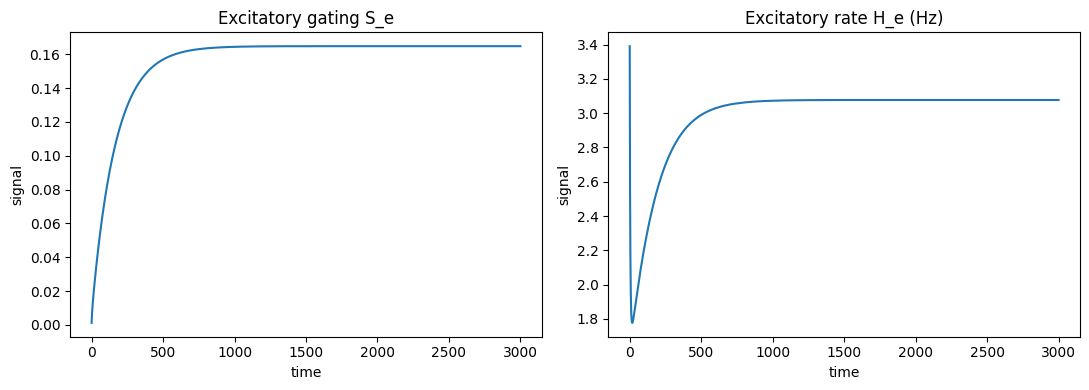

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
brainmass.viz.plot_timeseries(res['S_e'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Excitatory gating S_e')
brainmass.viz.plot_timeseries(res['rate_e'], ts=res['ts'], ax=axes[1])
axes[1].set_title('Excitatory rate H_e (Hz)')
plt.tight_layout()
plt.show()

## Try it: vary the feedback inhibition `J_i`

The feedback-inhibition weight `J_i` sets the E-I balance. Stronger inhibition clamps the excitatory rate lower; weaker inhibition lets it climb. We report the settled excitatory rate.

In [5]:
for J_i in [0.5, 1.0, 1.5]:
    m = brainmass.WongWangExcInhStep(in_size=1, J_i=J_i, G=2.0)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        3000. * u.ms, monitors={'rate_e': lambda m: m.H_e()})
    rate = float(u.get_magnitude(r['rate_e'])[-1, 0])
    print(f'J_i = {J_i:.1f}  ->  resting excitatory rate = {rate:.2f} Hz')

J_i = 0.5  ->  resting excitatory rate = 17.81 Hz
J_i = 1.0  ->  resting excitatory rate = 3.08 Hz


J_i = 1.5  ->  resting excitatory rate = 1.28 Hz
